Liver Disease Analysis — Indian Liver Patient Dataset

Author: Abdul Wahab, MBBS Dataset: Indian Liver Patient Dataset (Kaggle / UCI ML Repository), 583 patients, 11 clinical & demographic features


Introduction

Liver disease remains a major cause of morbidity worldwide, and routine liver function tests (LFTs) — bilirubin, alkaline phosphatase, transaminases (ALT/AST), total protein, and albumin — form the backbone of hepatobiliary screening. This project applies exploratory data analysis (EDA) techniques from Python's NumPy, Pandas, and Seaborn libraries to the Indian Liver Patient Dataset, with the aim of:

1. Understanding the distribution and quality of the data (missingness, outliers, ranges).
2. Identifying patient subgroups (by age, gender, disease status) that show distinct enzyme profiles.
3. Quantifying which liver markers are most strongly associated with disease status.
4. Communicating these findings visually, in a form suitable for clinical review.

This analysis is exploratory and descriptive in nature — it is intended to surface patterns and generate hypotheses, not to establish diagnostic thresholds or causal claims.


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [2]:
df = pd.read_csv("indian_liver_patient.csv")

In [3]:
df

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [4]:
# renaming columns and correcting:

df = df.rename(columns= {
    "Dataset" : "Diseased",
    "Total_Protiens" : "Total_Proteins",
    "Alamine_Aminotransferase" : "Alanine_Aminotransferase"
}) 
df["Diseased"] = df["Diseased"].replace({
    1 : "Yes",
    2 : "No"
})

df

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alanine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Diseased
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Yes
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Yes
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Yes
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Yes
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Yes
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,No
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,Yes
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,Yes
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,Yes


In [5]:
#counting how many patients are diseased and how many aren't:

df["Diseased"].value_counts()

Diseased
Yes    416
No     167
Name: count, dtype: int64

1. Data Overview & NumPy Fundamentals

The dataset contains 583 patients across 11 columns, including demographics (Age, Gender) and eight liver function markers (Total/Direct Bilirubin, Alkaline Phosphatase, ALT, AST, Total Proteins, Albumin, and the Albumin/Globulin Ratio). The target variable (Diseased) was recoded from its original numeric form (1/2) into readable labels (Yes/No) for clarity throughout the analysis.

A quick NumPy-level check on Total_Bilirubin confirmed a clean 1-dimensional numeric array (583 values, float64), consistent with what pandas reports — a useful sanity check before deeper analysis. Examining Alanine_Aminotransferase (ALT) directly via NumPy revealed a mean of ~80.7 U/L and a maximum of 2000 U/L — both well above the normal clinical reference range (roughly 7–56 U/L), indicating this dataset is weighted toward patients with more significant liver dysfunction rather than a general population sample.


In [6]:
# Checking Total bili on numpy:

arr1 = np.array(df["Total_Bilirubin"])
arr1

array([ 0.7, 10.9,  7.3,  1. ,  3.9,  1.8,  0.9,  0.9,  0.9,  0.7,  0.6,
        2.7,  0.9,  1.1,  0.7,  0.6,  1.8,  1.6,  0.9,  0.9,  2.2,  2.9,
        6.8,  1.9,  0.9,  4.1,  4.1,  6.2,  1.1,  0.7,  4. ,  0.9,  1. ,
        2.6,  2.6,  1.3,  0.7, 14.2,  1.4,  2.7,  2.4,  0.6,  6.8,  2.6,
        1. ,  1.8,  3.9,  1.1,  0.6, 18.4,  0.7,  0.6,  3.1,  1.1,  8.9,
        8.9,  0.8,  0.9,  0.8,  1.1,  0.8,  1. ,  1. ,  0.7,  1.3,  1.4,
        2.2,  1.8,  0.7,  0.8,  0.7,  0.8,  0.8,  0.6,  0.7,  0.7,  0.9,
        0.6,  1.4,  2.8,  2.4,  1. ,  0.7,  2. ,  0.6,  1.4,  0.6,  0.8,
        0.6,  4. ,  5.7,  6.8,  8.6,  5.8,  5.2,  0.9,  3.8,  6.6,  0.6,
        0.7,  0.6,  0.7,  0.9,  0.8,  0.5,  5.3,  5.3,  0.8,  0.8,  0.9,
        0.7,  3.2,  1.2,  0.6,  5.8,  7.3,  0.7, 12.7, 15.9, 18. , 23. ,
       22.7,  1.7,  0.8,  0.6,  1.8,  5.8,  3. ,  1.7,  2.8,  3.2,  0.7,
        0.8,  0.9,  1.8, 11.3,  4.7,  0.8,  0.8,  0.8,  0.6,  4.2,  1.6,
        1.6,  3.5,  0.8,  2.9,  0.7,  0.9,  0.8,  1

In [7]:
# shape of array 

arr1.shape

(583,)

In [8]:
# integer number of dimension of array

arr1.ndim

1

In [9]:
# Datatype of array

arr1.dtype

dtype('float64')

In [10]:
# max value of Alanine_Aminotransferase

arr2 = np.array(df["Alanine_Aminotransferase"])
arr2.max()

np.int64(2000)

In [11]:
# mean value of Alanine_Aminotransferase

arr2.mean()

np.float64(80.71355060034305)

2. Data Cleaning & Boolean Filtering

Checking for missing data revealed 4 patients with a missing Albumin_and_Globulin_Ratio value — a small, manageable gap that doesn't meaningfully affect the analysis but is worth disclosing for transparency.

Filtering patients over age 50 with a positive diagnosis identified 158 patients — a substantial subgroup, useful for age-stratified follow-up analysis if extended further.

As a data-quality exercise, Total_Bilirubin values were capped at 20 mg/dL purely for visualization purposes (a small number of extreme outliers, up to 75 mg/dL, would otherwise distort chart scaling). This is explicitly a display-only adjustment — real extreme bilirubin values are clinically meaningful and would never be altered before actual diagnostic or modeling work.

In [12]:
# missing values in Albumin_and_Globulin_Ratio

df["Albumin_and_Globulin_Ratio"].isnull().sum()

np.int64(4)

In [13]:
# all patients over age 50 with liver disease

df.loc[(df["Age"] > 50) & (df["Diseased"] == "Yes")]


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alanine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Diseased
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Yes
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Yes
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Yes
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Yes
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Yes
...,...,...,...,...,...,...,...,...,...,...,...
562,66,Male,17.3,8.5,388,173,367,7.8,2.6,0.50,Yes
563,64,Male,1.4,0.5,298,31,83,7.2,2.6,0.50,Yes
567,52,Male,2.7,1.4,251,20,40,6.0,1.7,0.39,Yes
571,90,Male,1.1,0.3,215,46,134,6.9,3.0,0.70,Yes


In [14]:
# change the value of total bili > 20 to 20

# df.loc[df["Total_Bilirubin"] > 20, "Total_Bilirubin"] = 20
# df.loc[df["Total_Bilirubin"] == 20]

3. Grouped Statistics & Notable Cases

Average Total_Bilirubin differed by gender: Females averaged 2.32 mg/dL, while Males averaged 3.61 mg/dL — a noteworthy gap worth flagging, though this dataset does not allow us to say why (it may reflect referral patterns rather than true biological sex differences, given the sample is not gender-balanced).

The patient with the single highest ALT value in the dataset (patient index 117, a 32-year-old male) showed a strikingly severe enzyme profile: ALT of 2000 U/L and AST of 2946 U/L, alongside elevated bilirubin (12.7 mg/dL total, 6.2 mg/dL direct). This is consistent with an acute, severe hepatocellular injury pattern and stands out as a case worth discussing separately from the general trend, as a single outlier of this magnitude can disproportionately affect summary statistics.

Ranking patients by Albumin/Globulin ratio (ascending) identified the 3rd-lowest case (patient index 533, a 46-year-old female) with a ratio of just 0.3, alongside elevated ALT (509) and AST (623) — a profile suggestive of chronic liver dysfunction with impaired albumin synthesis.

In [15]:
# average total bili per gender 

df.groupby("Gender")["Total_Bilirubin"].mean()

Gender
Female    2.322535
Male      3.613152
Name: Total_Bilirubin, dtype: float64

In [16]:
# highest ALT among Liver patients

df.loc[df["Diseased"] == "Yes"].sort_values("Alanine_Aminotransferase",ascending= False).iloc[0]

Age                             32
Gender                        Male
Total_Bilirubin               12.7
Direct_Bilirubin               6.2
Alkaline_Phosphotase           194
Alanine_Aminotransferase      2000
Aspartate_Aminotransferase    2946
Total_Proteins                 5.7
Albumin                        3.3
Albumin_and_Globulin_Ratio     1.3
Diseased                       Yes
Name: 117, dtype: object

In [17]:
# Patient with 3rd lowest ratio for Albumin_and_Globulin_Ratio

df.sort_values("Albumin_and_Globulin_Ratio",ascending=True).iloc[2]

Age                             50
Gender                        Male
Total_Bilirubin                7.3
Direct_Bilirubin               3.7
Alkaline_Phosphotase            92
Alanine_Aminotransferase        44
Aspartate_Aminotransferase     236
Total_Proteins                 6.8
Albumin                        1.6
Albumin_and_Globulin_Ratio     0.3
Diseased                       Yes
Name: 401, dtype: object

4. Visualizations

Chart 1 — Average Total Bilirubin by Gender and Disease Status (Bar Chart) This chart splits average bilirubin by both gender and disease status simultaneously. Both male and female diseased patients show clearly higher average bilirubin than their non-diseased counterparts, and the gap between disease groups is far larger than the gap between genders — suggesting disease status, not sex, is the primary driver of elevated bilirubin in this dataset. As with all group averages, this can be skewed by outliers (such as patient 117) and should be read alongside the underlying spread, not in isolation.

Chart 2 — Age Distribution by Disease Status (Histogram) Overlaying age distributions for diseased vs. non-diseased patients shows that diagnosed patients are concentrated in the 40–60 age range, while non-diseased patients are fewer and more thinly spread across ages. This is consistent with liver disease prevalence generally increasing with age, though the disease group's much larger sample size (416 vs. 167) makes a direct height comparison somewhat misleading — proportional comparison would be a natural next step.

Chart 3 — Correlation of Liver Markers with Disease Status (Ranked Bar Chart) Ranking each numeric marker by its correlation with disease status revealed Direct Bilirubin (r ≈ 0.25) and Total Bilirubin (r ≈ 0.22) as the strongest positive associations, followed by Alkaline Phosphatase, ALT, and AST — all pointing the expected direction (higher enzyme/bilirubin levels associated with disease). Albumin (r ≈ -0.16) and the Albumin/Globulin Ratio (r ≈ -0.16) showed the strongest negative associations, consistent with the liver's role in albumin synthesis being impaired in disease. Notably, all correlations are weak-to-moderate in magnitude (none exceed 0.3) — no single marker strongly predicts disease status alone, which mirrors real clinical practice, where diagnosis relies on a combination of findings rather than any one lab value in isolation.

<Axes: xlabel='Gender', ylabel='Total_Bilirubin'>

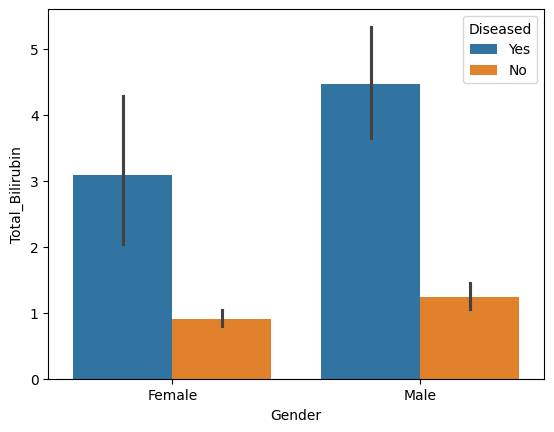

In [18]:
# Bar chart: average Total_Bilirubin by Gender, but split further by disease status

sns.barplot(data= df, x= "Gender", y= "Total_Bilirubin", hue= "Diseased")

<Axes: xlabel='Age', ylabel='Count'>

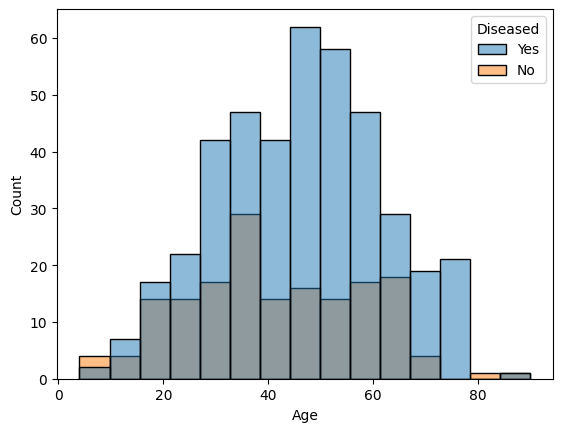

In [19]:
# Histogram: distribution of Age, comparing diseased vs non-diseased patients

sns.histplot(data= df, x= "Age", hue= "Diseased")

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Direct_Bilirubin'),
  Text(1, 0, 'Total_Bilirubin'),
  Text(2, 0, 'Alkaline_Phosphotase'),
  Text(3, 0, 'Alanine_Aminotransferase'),
  Text(4, 0, 'Aspartate_Aminotransferase'),
  Text(5, 0, 'Age'),
  Text(6, 0, 'Total_Proteins'),
  Text(7, 0, 'Albumin'),
  Text(8, 0, 'Albumin_and_Globulin_Ratio')])

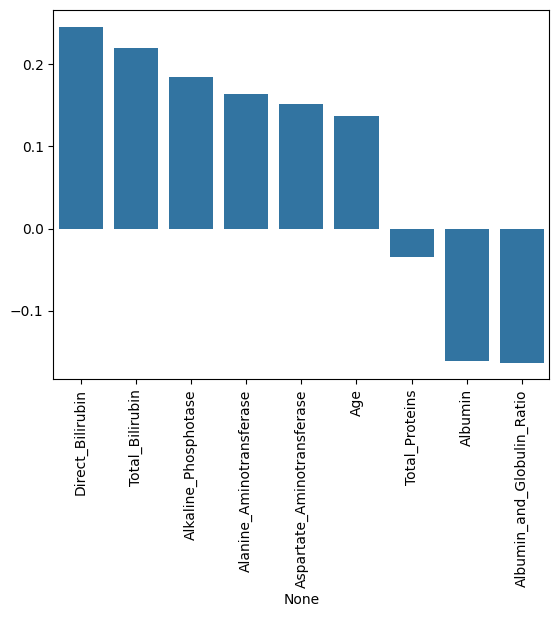

In [22]:
 # corelation of liver enzymes with disease status

df["Diseased_numerical"] = df["Diseased"].map({"Yes" : 1, "No" : 0})

corelation_matrix = df[["Age", "Total_Bilirubin", "Direct_Bilirubin", "Alkaline_Phosphotase", "Alanine_Aminotransferase", "Aspartate_Aminotransferase", "Total_Proteins", "Albumin", "Albumin_and_Globulin_Ratio", "Diseased_numerical" ]].corr()
liver_pts = corelation_matrix["Diseased_numerical"]
liver_pts_sorted = liver_pts.sort_values(ascending= False)
liver_pts_sorted = liver_pts_sorted.drop("Diseased_numerical")
sns.barplot(x= liver_pts_sorted.index, y= liver_pts_sorted.values)
plt.xticks(rotation= 90)

5. Key Findings — Summary

1) The dataset comprises 583 patients, with a notable class imbalance: 416 diagnosed with liver disease (71.4%) vs. 167 without (28.6%) — important context for any future modeling work, as this imbalance would need to be addressed to avoid biased predictions.
2) Liver enzyme and bilirubin levels in this dataset skew markedly high overall (mean ALT ~81 U/L vs. a normal upper limit of ~56 U/L), reflecting a patient population already enriched for significant liver pathology rather than a general screening population.
3) Direct and Total Bilirubin showed the strongest positive correlation with disease status, while Albumin and Albumin/Globulin Ratio showed the strongest negative correlation — both directionally consistent with known liver physiology (impaired bile processing raises bilirubin; impaired protein synthesis lowers albumin).
4) No single marker showed a strong (>0.3) correlation with disease status in isolation, reinforcing that liver disease diagnosis is inherently multi-factorial and unlikely to be captured by any single lab value.
5) Individual outlier cases (e.g., patient 117, ALT 2000 / AST 2946) highlight the importance of examining extreme values individually rather than relying solely on group averages, which can be distorted by a small number of severe cases.
6) Limitations: This analysis is descriptive and correlational only — no causal claims are made, and the class imbalance and lack of longitudinal data limit generalizability. Future work could include proportional (rather than raw count) comparisons across age groups, and formal statistical testing (e.g., t-tests) to confirm whether observed group differences are statistically significant.

Analysis conducted using Python (NumPy, Pandas, Seaborn/Matplotlib) as part of an ongoing Clinical AI / Data Science learning program.